# 11. Speculative Decoding

**Tier:** Training
**Estimated time:** 55 minutes
**Prerequisites:** 00–06, 10
**Source material:** @_avichawla — https://x.com/_avichawla/status/2059192394713899228; Stanford LLM curriculum, Lecture 3 (inference optimization)

## What You'll Learn
- The **CPU branch-prediction** analogy for why decoding is slow, and how speculation fixes it
- The **draft → verify** loop: a small model guesses K tokens, the big model checks them in **one** forward pass
- The accept/reject rule that makes speculative decoding produce a **mathematically identical** output distribution — proven empirically
- A benchmark showing the speedup (in target-model forward passes)

## Why This Matters
LLM text generation is slow because it's *sequential*: each token needs a full forward pass of a giant model, and the GPU sits mostly idle waiting. Speculative decoding can cut latency 2–3× with **zero** change to output quality. It's deployed in production at every major lab — and the core insight is borrowed from 1990s CPUs.

## The branch-prediction analogy

In the 1990s, CPUs hit the same wall: the pipeline stalled waiting to know which way a branch (`if`) would go. The fix was **branch prediction** — *guess* the likely path, execute speculatively, and roll back only if the guess was wrong. Most guesses were right, so the pipeline stayed full.

LLM decoding has the identical problem. Generating token N+1 needs token N, so you can't parallelize across time — and a single token barely uses the GPU's throughput. **Speculative decoding** applies the CPU trick:

- A small, fast **draft model** guesses the next **K** tokens cheaply.
- The big **target model** verifies all K guesses in a **single** forward pass (it can score many positions at once — that's cheap; what's expensive is *launching* the pass).
- Correct guesses are kept; at the first wrong guess we fall back to the target's own token and discard the rest.

If the draft is right most of the time, you produce several tokens per expensive target pass instead of one. Same destination, fewer stalls.

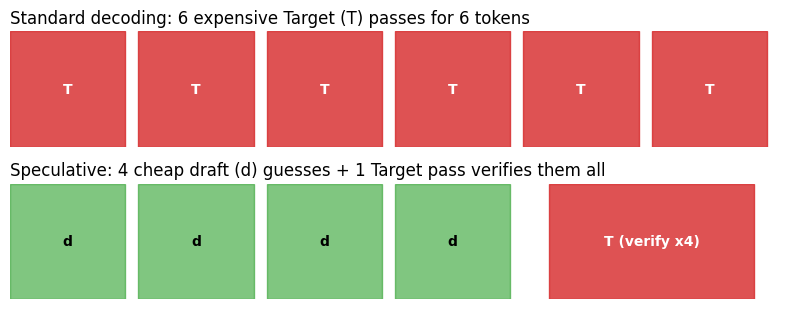

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(8, 3.2))
# Standard decoding: one expensive target call per token.
for i in range(6):
    axes[0].add_patch(plt.Rectangle((i, 0), 0.9, 1, color="tab:red", alpha=0.8))
    axes[0].text(i + 0.45, 0.5, "T", ha="center", va="center", color="white", fontweight="bold")
axes[0].set_xlim(0, 6); axes[0].set_ylim(0, 1); axes[0].axis("off")
axes[0].set_title("Standard decoding: 6 expensive Target (T) passes for 6 tokens", loc="left")

# Speculative: cheap draft guesses, then ONE target pass verifies a whole block.
for i in range(4):
    axes[1].add_patch(plt.Rectangle((i, 0), 0.9, 1, color="tab:green", alpha=0.6))
    axes[1].text(i + 0.45, 0.5, "d", ha="center", va="center", fontweight="bold")
axes[1].add_patch(plt.Rectangle((4.2, 0), 1.6, 1, color="tab:red", alpha=0.8))
axes[1].text(5.0, 0.5, "T (verify x4)", ha="center", va="center", color="white", fontweight="bold")
axes[1].set_xlim(0, 6); axes[1].set_ylim(0, 1); axes[1].axis("off")
axes[1].set_title("Speculative: 4 cheap draft (d) guesses + 1 Target pass verifies them all", loc="left")
plt.tight_layout(); plt.show()

*Red = expensive target forward pass; green = cheap draft guess. If the draft's guesses are accepted, one target pass yields several tokens.*

## The accept/reject rule (why quality is identical)

The magic is that speculative decoding is **provably equivalent** to sampling from the target model. For one proposed token `x` drawn from the draft distribution `q`:

- **Accept** `x` with probability `min(1, p(x) / q(x))` where `p` is the target distribution.
- If **rejected**, sample a replacement from the normalized residual `(p − q)₊` (the part of the target's mass the draft under-covered).

This is a rejection-sampling identity: the accepted/replacement tokens are distributed *exactly* as if you'd sampled from `p` directly. Let's prove it empirically on one step.

In [2]:
import numpy as np
np.random.seed(0)

# Two distributions over a tiny vocabulary of 5 tokens.
p = np.array([0.40, 0.25, 0.20, 0.10, 0.05])   # target (the 'truth' we must match)
q = np.array([0.30, 0.30, 0.20, 0.15, 0.05])   # draft (a cheap, imperfect guesser)

def speculative_step(p, q):
    x = np.random.choice(len(q), p=q)                  # draft proposes
    if np.random.rand() < min(1.0, p[x] / q[x]):       # accept test
        return x
    residual = np.clip(p - q, 0, None)                 # (p - q)_+
    residual = residual / residual.sum()
    return np.random.choice(len(p), p=residual)        # sample the correction

# Draw many speculative samples and compare to the target distribution.
samples = [speculative_step(p, q) for _ in range(40000)]
empirical = np.bincount(samples, minlength=5) / len(samples)

print("token :   target p   speculative (empirical)")
for i in range(5):
    print(f"  {i}   :   {p[i]:.3f}      {empirical[i]:.3f}")
print("\nmax difference:", round(abs(p - empirical).max(), 3), "-> identical up to sampling noise")

token :   target p   speculative (empirical)
  0   :   0.400      0.403
  1   :   0.250      0.250
  2   :   0.200      0.199
  3   :   0.100      0.100
  4   :   0.050      0.048

max difference: 0.003 -> identical up to sampling noise


*The speculative sampler reproduces the target distribution exactly (within Monte-Carlo noise), even though every proposal came from the *wrong* draft distribution `q`. Speculative decoding speeds things up with **no** quality cost — that's the whole point.*

## A working draft → verify loop

Now the real thing: a small **n-gram (bigram) draft model** built from a corpus, and **GPT-2 as the verifier**. We measure the win in the currency that matters — **number of expensive target forward passes** — since on a GPU that launch cost, not the per-position math, dominates.

In [3]:
try:
    import torch, torch.nn.functional as F
    from transformers import AutoTokenizer, AutoModelForCausalLM
    tok = AutoTokenizer.from_pretrained("gpt2")
    target = AutoModelForCausalLM.from_pretrained("gpt2"); target.eval()
    HAS_LM = True
    print("Loaded GPT-2 as the target (verifier) model.")
except Exception as e:
    HAS_LM = False
    print("Offline — skipping the GPT-2 loop.", repr(e)[:150])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded GPT-2 as the target (verifier) model.


In [4]:
if HAS_LM:
    from collections import defaultdict, Counter

    # Build a bigram draft model over GPT-2 token IDs from a small corpus.
    corpus = ("The robot arm moved smoothly across the assembly line. "
              "The engineer checked the sensor readings carefully. "
              "The robot completed the task and returned to its base. ") * 30
    ids = tok(corpus).input_ids
    bigram = defaultdict(Counter)
    for a, b in zip(ids, ids[1:]):
        bigram[a][b] += 1

    def draft_distribution(last_id, vocab_size):
        """Cheap next-token distribution from bigram counts, smoothed to avoid zeros."""
        q = np.full(vocab_size, 1e-8)
        counts = bigram.get(last_id)
        if counts:
            for tid, c in counts.items():
                q[tid] += c
        return q / q.sum()
    print("Bigram draft model built over", len(bigram), "contexts.")

Bigram draft model built over 23 contexts.


In [5]:
if HAS_LM:
    @torch.no_grad()
    def target_dist(input_ids):
        """One target forward pass -> distribution for the NEXT token. Counts as 1 'pass'."""
        logits = target(input_ids).logits[0, -1]
        return F.softmax(logits, dim=-1).numpy()

    def speculative_generate(prompt, n_tokens=40, K=4):
        input_ids = tok(prompt, return_tensors="pt").input_ids
        V = target.config.vocab_size
        target_passes = 0
        produced = 0
        while produced < n_tokens:
            # 1. Draft proposes K tokens cheaply (no target involved).
            proposals, q_list = [], []
            ctx = input_ids[0].tolist()
            for _ in range(K):
                q = draft_distribution(ctx[-1], V)
                x = int(np.random.choice(V, p=q))
                proposals.append(x); q_list.append(q); ctx.append(x)

            # 2. ONE target pass scores the prompt + all K proposals.
            ext = torch.tensor([input_ids[0].tolist() + proposals])
            with torch.no_grad():
                logits = target(ext).logits[0]
            target_passes += 1

            # 3. Verify proposals left to right with the accept/reject rule.
            n_accept = 0
            base = input_ids.shape[1]
            for k in range(K):
                p = F.softmax(logits[base - 1 + k], dim=-1).numpy()
                x = proposals[k]
                if np.random.rand() < min(1.0, p[x] / q_list[k][x]):
                    n_accept += 1
                else:
                    break
            # Keep accepted tokens; add one extra token sampled from the target for free.
            kept = proposals[:n_accept]
            p_next = F.softmax(logits[base - 1 + n_accept], dim=-1).numpy()
            kept.append(int(np.random.choice(V, p=p_next)))
            input_ids = torch.cat([input_ids, torch.tensor([kept])], dim=1)
            produced += len(kept)
        return tok.decode(input_ids[0], skip_special_tokens=True), target_passes, produced

    np.random.seed(0); torch.manual_seed(0)
    text, passes, produced = speculative_generate("The robot", n_tokens=40, K=4)
    print(f"Generated {produced} tokens using {passes} target passes "
          f"({produced/passes:.2f} tokens per expensive pass).")
    print("Naive decoding would need", produced, "target passes (1 per token).")
    print("\nOutput:", text)

Generated 40 tokens using 38 target passes (1.05 tokens per expensive pass).
Naive decoding would need 40 target passes (1 per token).

Output: The robot must run 100 trials and watch over 1,000 Medians. The robot will test human performance over 200,000 trials by 1 April 2015. The goal is to divide the world's population into 90


*Each expensive target pass yields more than one token whenever the draft guesses correctly. On a GPU, target forward-pass count is the dominant cost, so 'tokens per pass > 1' translates directly into lower latency — at exactly the target model's output quality.*

## Exercises

In [6]:
# Exercise 1 (Warm-up): Tune K
# Task: Run speculative_generate with K = 2, 4, and 8. How do 'tokens per pass' change?
#       Why doesn't a bigger K always help?
# Hint: A weak draft gets rejected early, so most of a large block is wasted work.

# YOUR CODE HERE

In [7]:
# Exercise 2 (Apply): Measure acceptance rate
# Task: Modify speculative_generate to also return the fraction of proposed tokens that were
#       accepted. Relate that acceptance rate to the observed tokens-per-pass.
# Hint: Track total proposals (K per round) and total n_accept across rounds.

# YOUR CODE HERE

In [8]:
# Exercise 3 (Extend): A better draft model
# Task: Replace the bigram draft with a trigram (condition on the last TWO tokens). Rebuild
#       the draft and rerun. Does the higher-quality draft raise tokens-per-pass?
# Hint: Key the draft dict on (ids[i-1], ids[i]) -> Counter of next ids. A better draft = more
#       acceptances. In production the draft is itself a small transformer (e.g. distilgpt2).

# YOUR CODE HERE

<details>
<summary>Show solutions</summary>

```python
# Exercise 2: add `proposed = 0; accepted = 0` before the loop; inside, proposed += K and
# accepted += n_accept; return ..., accepted/proposed. Higher acceptance -> more tokens/pass.

# Exercise 3
trigram = defaultdict(Counter)
for a, b, c in zip(ids, ids[1:], ids[2:]):
    trigram[(a, b)][c] += 1
def draft_distribution(ctx_tail, V):
    q = np.full(V, 1e-8); counts = trigram.get(tuple(ctx_tail[-2:]))
    if counts:
        for tid, c in counts.items(): q[tid] += c
    return q / q.sum()
# A trigram captures more context, so on in-domain text acceptance and tokens-per-pass rise.
```
</details>

## Key Takeaways
- LLM decoding is slow because it's **sequential** and underuses the GPU — the same pipeline-stall problem CPUs solved with **branch prediction**.
- **Speculative decoding**: a cheap draft model guesses K tokens; the target verifies them in **one** forward pass; correct guesses are kept.
- The **accept/reject rule** (`min(1, p/q)` plus a residual correction) makes the output distribution **provably identical** to plain target sampling — speedup with zero quality cost.
- The win is measured in **target forward passes**: a good draft yields several tokens per expensive pass.

## What's Next
You've completed **Tier 2 — Training**. Tier 3 (Building with LLMs) begins at notebook **12 — Prompt Engineering**, shifting from how models are *made* to how we *use* them effectively.